In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session


# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


# 1. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing


In [3]:
df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

In [4]:
df

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


# 2. Data Overview

In [5]:
df.shape

(2640, 12)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [7]:
df.describe(include='all')

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


In [8]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [9]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [10]:
df.columns.tolist()

['Year',
 'Month',
 'Region',
 'Model',
 'Estimated_Deliveries',
 'Production_Units',
 'Avg_Price_USD',
 'Battery_Capacity_kWh',
 'Range_km',
 'CO2_Saved_tons',
 'Source_Type',
 'Charging_Stations']

In [11]:
print("Regions:", df['Region'].unique())
print("Models:", df['Model'].unique())
print("Source Types:", df['Source_Type'].unique())

Regions: ['Europe' 'Asia' 'North America' 'Middle East']
Models: ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']
Source Types: ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [12]:
df['Region'].value_counts()

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64

In [13]:
df['Source_Type'].value_counts()

Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

# 3. Data Preprocessing

In [15]:
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str)
)

df.sort_values('Date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Shape after cleaning : {df.shape}")
print(f"Date range : {df['Date'].min().strftime('%b %Y')} - {df['Date'].max().strftime('%b %Y')}")
df[['Year', 'Month', 'Date']].drop_duplicates().head(8)

Shape after cleaning : (2640, 13)
Date range : Jan 2015 - Dec 2025


,Year,Month,Date
0,2015,1,2015-01-01
20,2015,2,2015-02-01
40,2015,3,2015-03-01
60,2015,4,2015-04-01
80,2015,5,2015-05-01
100,2015,6,2015-06-01
120,2015,7,2015-07-01
140,2015,8,2015-08-01


# 4. EDA

## 4.1 Production and Deliveries over time

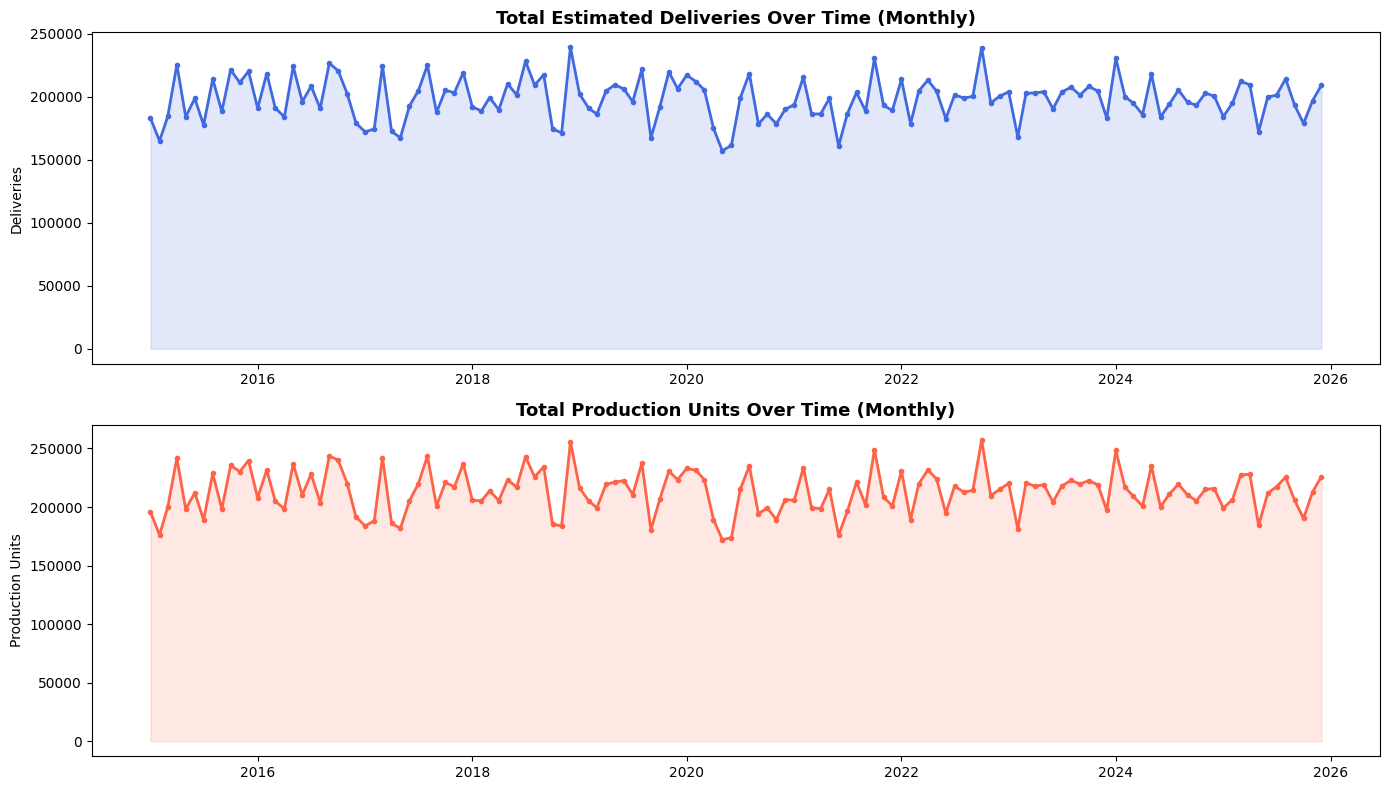

In [16]:
deliveries_ts  = df.groupby('Date')['Estimated_Deliveries'].sum()
production_ts  = df.groupby('Date')['Production_Units'].sum()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(deliveries_ts.index, deliveries_ts.values,
             color='royalblue', linewidth=2, marker='o', markersize=3)
axes[0].fill_between(deliveries_ts.index, deliveries_ts.values, alpha=0.15, color='royalblue')
axes[0].set_title('Total Estimated Deliveries Over Time (Monthly)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Deliveries')

axes[1].plot(production_ts.index, production_ts.values,
             color='tomato', linewidth=2, marker='o', markersize=3)
axes[1].fill_between(production_ts.index, production_ts.values, alpha=0.15, color='tomato')
axes[1].set_title('Total Production Units Over Time (Monthly)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Production Units')

plt.tight_layout()
plt.show()

## 4.2 Breakdown by Model and Region

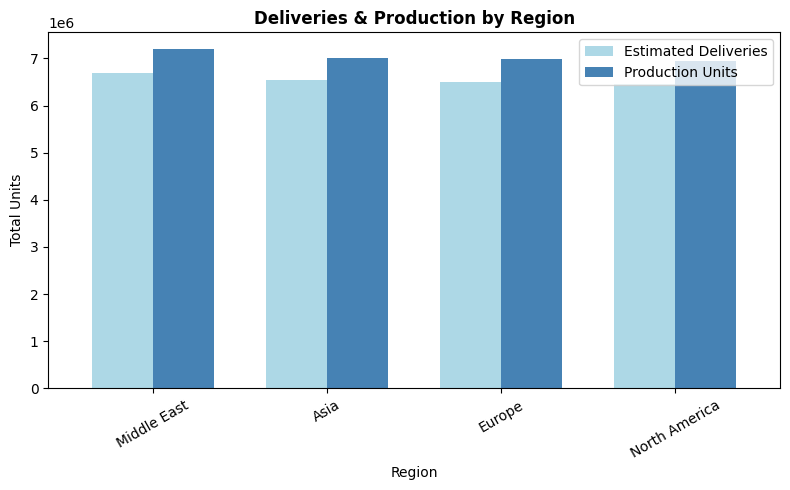

In [17]:
region = df.groupby('Region')[['Estimated_Deliveries', 'Production_Units']]\
           .sum().sort_values('Estimated_Deliveries', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
region.plot(kind='bar', stacked=False, ax=ax, 
            color=['lightblue', 'steelblue'], width=0.7)
ax.set_title('Deliveries & Production by Region', fontweight='bold')
ax.set_ylabel('Total Units')
ax.set_xlabel('Region')
ax.tick_params(axis='x', rotation=30)
ax.legend(['Estimated Deliveries', 'Production Units'])
plt.tight_layout()
plt.show()

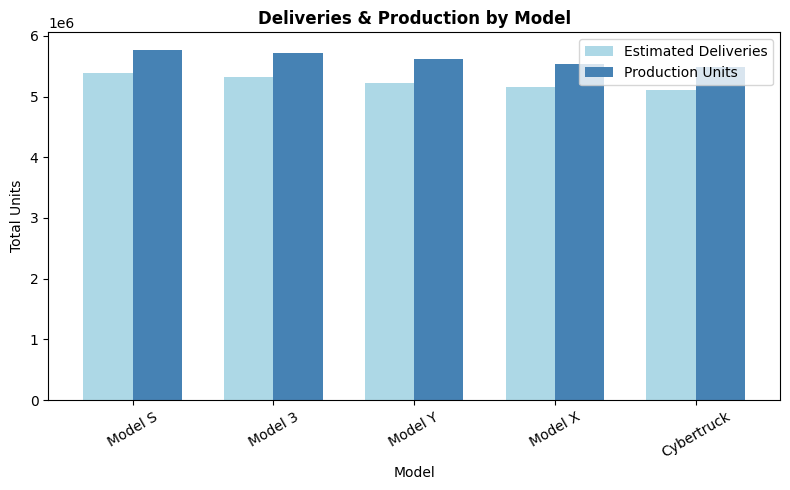

In [18]:
model = df.groupby('Model')[['Estimated_Deliveries', 'Production_Units']]\
          .sum().sort_values('Estimated_Deliveries', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
model.plot(kind='bar', stacked=False, ax=ax,
           color=['lightblue', 'steelblue'], width=0.7)
ax.set_title('Deliveries & Production by Model', fontweight='bold')
ax.set_ylabel('Total Units')
ax.set_xlabel('Model')
ax.tick_params(axis='x', rotation=30)
ax.legend(['Estimated Deliveries', 'Production Units'])
plt.tight_layout()
plt.show()

## 4.3 Model Comparison

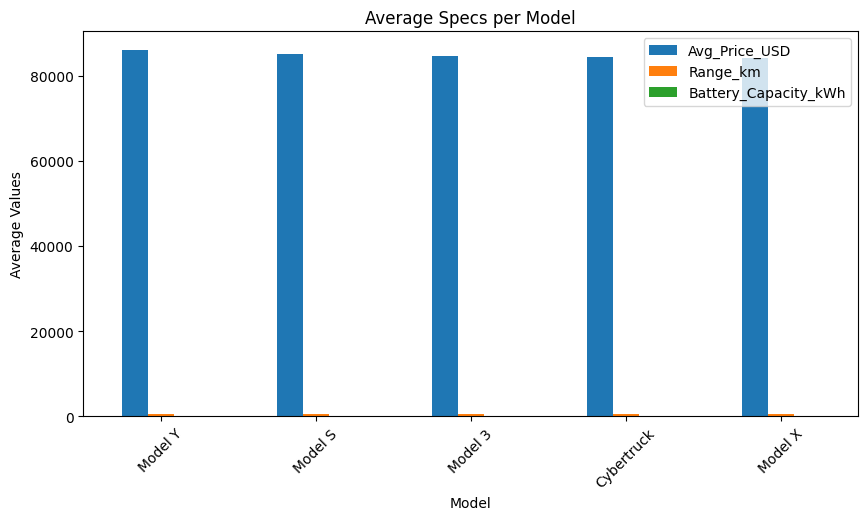

In [19]:
model_stats = df.groupby('Model')[['Avg_Price_USD', 'Range_km', 'Battery_Capacity_kWh']].mean().sort_values('Avg_Price_USD', ascending=False)
model_stats.plot(kind='bar', figsize=(10,5))
plt.title('Average Specs per Model')
plt.ylabel('Average Values')
plt.xticks(rotation=45)
plt.show()

## 4.4 CO2 savings and Charging Infrastructure

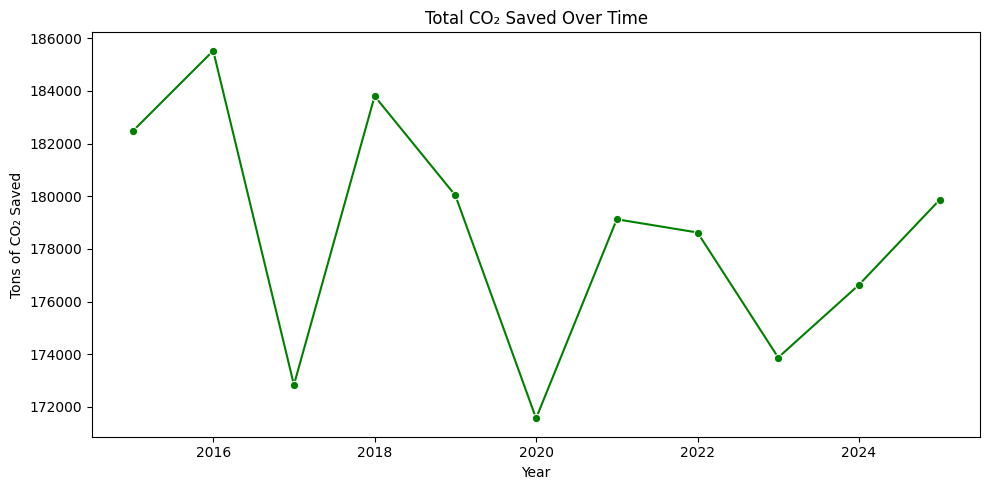

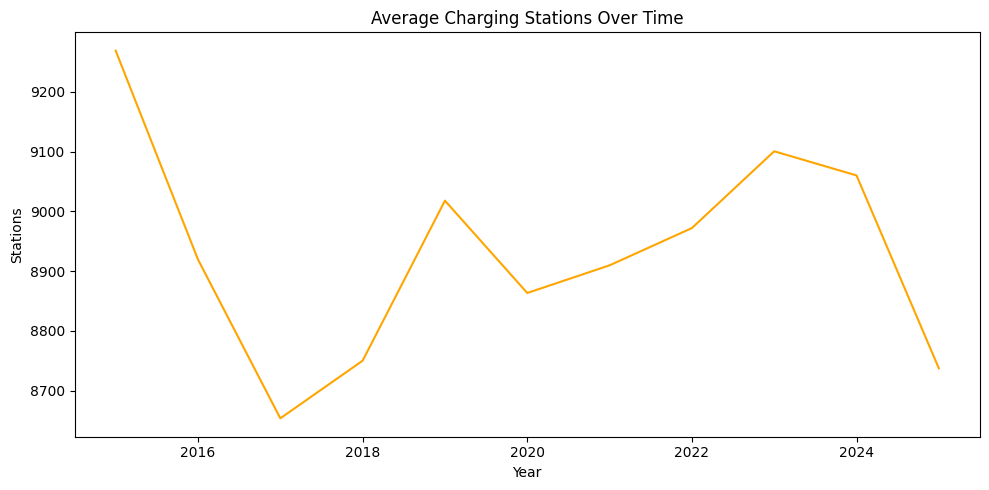

In [20]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df.groupby('Year')['CO2_Saved_tons'].sum().reset_index(),
             x='Year', y='CO2_Saved_tons', marker='o', color='green')
plt.title('Total CO₂ Saved Over Time')
plt.ylabel('Tons of CO₂ Saved')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))
sns.lineplot(data=df.groupby('Year')['Charging_Stations'].mean().reset_index(),
             x='Year', y='Charging_Stations', color='orange')
plt.title('Average Charging Stations Over Time')
plt.ylabel('Stations')
plt.tight_layout()
plt.show()

## 4.5 Distribution of avg price USD

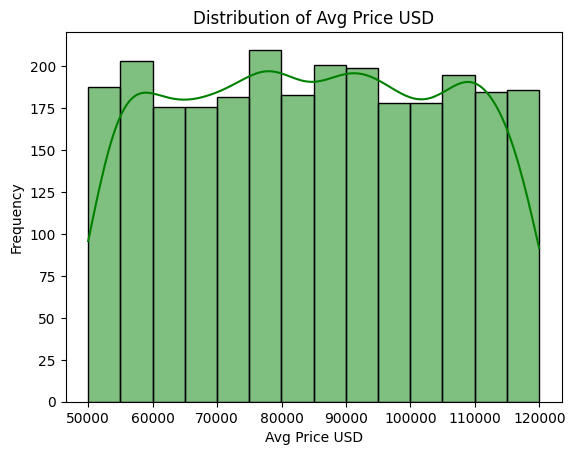

In [21]:
sns.histplot(df['Avg_Price_USD'],kde=True,color='green')
plt.xlabel('Avg Price USD')
plt.ylabel('Frequency')
plt.title('Distribution of Avg Price USD')
plt.show()

## 4.6 Heatmap

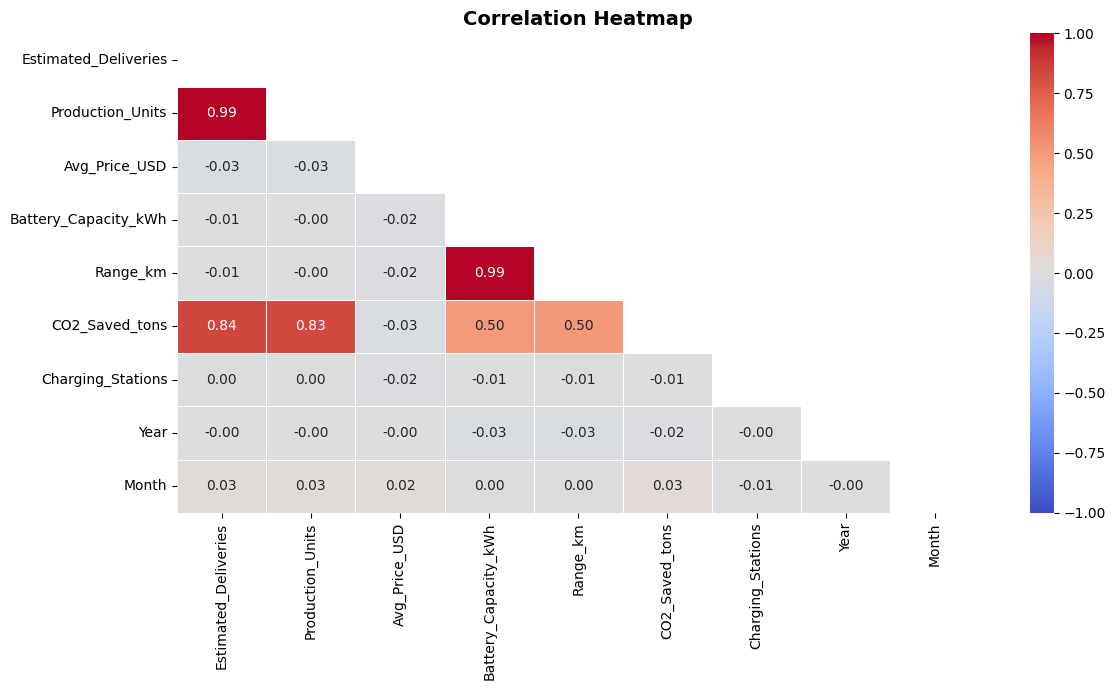

In [22]:
heatmap_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
                'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
                'Charging_Stations', 'Year', 'Month']

plt.figure(figsize=(12, 7))
corr = df[heatmap_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, annot_kws={'size': 10})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

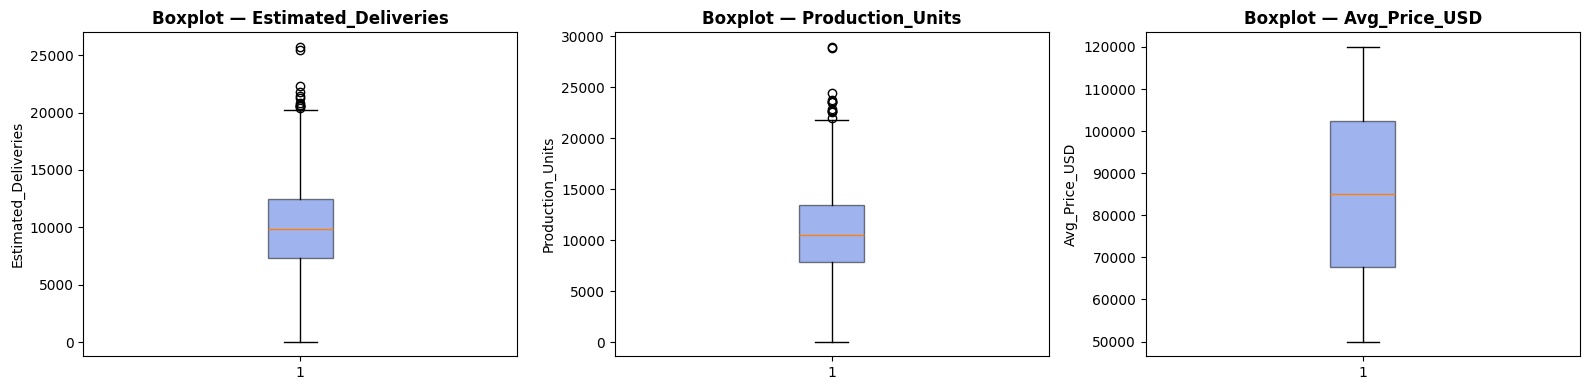

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

cols_check = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD']

for ax, col in zip(axes, cols_check):
    ax.boxplot(df[col], vert=True, patch_artist=True,
               boxprops=dict(facecolor='royalblue', alpha=0.5))
    ax.set_title(f'Boxplot — {col}', fontweight='bold')
    ax.set_ylabel(col)

plt.tight_layout()
plt.show()

# 5. Feature Engineering

In [24]:
df = df.sort_values('Date').reset_index(drop=True)

In [25]:
df['Deliveries_Lag1'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(1)
df['Deliveries_Lag2'] = df.groupby(['Region', 'Model'])['Estimated_Deliveries'].shift(2)

In [26]:
df['Deliveries_Rolling3'] = (
    df.groupby(['Region', 'Model'])['Estimated_Deliveries']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=2).mean())
)

In [27]:
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

In [28]:
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [29]:
print(f"Shape after feature engineering: {df.shape}")
print("New features added:")
print("  Deliveries_Lag1, Deliveries_Lag2, Deliveries_Rolling3")
print("  Month_sin, Month_cos")
df.head(3)

Shape after feature engineering: (2600, 18)
New features added:
  Deliveries_Lag1, Deliveries_Lag2, Deliveries_Rolling3
  Month_sin, Month_cos


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Deliveries_Lag1,Deliveries_Lag2,Deliveries_Rolling3,Month_sin,Month_cos
0,2015,3,Europe,Model S,11929,11956,114982.30,120,685,1225.70,Official (Quarter),14599,2015-03-01,6790.0,4350.0,5570.0,1.0,6.123234e-17
1,2015,3,Middle East,Model Y,5198,5319,67517.00,82,473,368.80,Interpolated (Month),11575,2015-03-01,11172.0,10348.0,10760.0,1.0,6.123234e-17
2,2015,3,Middle East,Cybertruck,8661,9518,69595.37,100,597,775.59,Estimated (Region),11854,2015-03-01,7142.0,8803.0,7972.5,1.0,6.123234e-17


In [30]:
df_encoded = pd.get_dummies(df, columns=['Region', 'Model', 'Source_Type'],
                             drop_first=True, dtype=int)

print(f"df_encoded shape: {df_encoded.shape}")
print(df_encoded.columns.tolist())

df_encoded shape: (2600, 24)
['Year', 'Month', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Date', 'Deliveries_Lag1', 'Deliveries_Lag2', 'Deliveries_Rolling3', 'Month_sin', 'Month_cos', 'Region_Europe', 'Region_Middle East', 'Region_North America', 'Model_Model 3', 'Model_Model S', 'Model_Model X', 'Model_Model Y', 'Source_Type_Interpolated (Month)', 'Source_Type_Official (Quarter)']


# 6. Train Test Split

In [31]:
target = 'Estimated_Deliveries'

leaky_cols = ['CO2_Saved_tons']

exclude_cols = ['Date', target] + leaky_cols

feature_cols = [c for c in df_encoded.columns if c not in exclude_cols]

print("Clean feature list:")
print(*feature_cols, sep='\n')
print(f"\nTotal features: {len(feature_cols)}")

Clean feature list:
Year
Month
Production_Units
Avg_Price_USD
Battery_Capacity_kWh
Range_km
Charging_Stations
Deliveries_Lag1
Deliveries_Lag2
Deliveries_Rolling3
Month_sin
Month_cos
Region_Europe
Region_Middle East
Region_North America
Model_Model 3
Model_Model S
Model_Model X
Model_Model Y
Source_Type_Interpolated (Month)
Source_Type_Official (Quarter)

Total features: 21


In [32]:
X = df_encoded[feature_cols]
y = df_encoded[target]

In [33]:
split_idx = int(len(df_encoded) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

* This decides how the dataset should be split
* len(df) = 2640. So split_idx = 2640 * 0.8 = 2112
* Training data - First 2112 rows
* Testing data - rest rows

In [34]:
numeric_cols = ['Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
                'Charging_Stations', 'Year', 'Month',
                'Deliveries_Lag1', 'Deliveries_Lag2', 'Deliveries_Rolling3',
                'Month_sin', 'Month_cos']

numeric_cols = [c for c in numeric_cols if c in X_train.columns]


In [35]:
scaler = StandardScaler()
X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

X_train_sc[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_sc[numeric_cols]  = scaler.transform(X_test[numeric_cols])

print(f"Train size : {X_train_sc.shape}")
print(f"Test size  : {X_test_sc.shape}")

Train size : (2080, 21)
Test size  : (520, 21)


# 7. Model Training

In [36]:
models = {
    'Linear Regression' : LinearRegression(),
    'Ridge' : Ridge(alpha=1.0),
    'Lasso' : Lasso(alpha=0.1) }


In [37]:
results = []
trained_models = {}

In [38]:
for name, model in models.items():
    model.fit(X_train_sc, y_train)
    
    preds = model.predict(X_test_sc)
    
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    
    results.append({'Model': name, 'MAE': round(mae, 2), 
                    'RMSE': round(rmse, 2), 'R²': round(r2, 4)})
    
    trained_models[name] = (model, preds)
results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)

print(results_df.to_string(index=False))

            Model    MAE   RMSE     R²
            Lasso 354.56 428.22 0.9863
            Ridge 354.75 428.33 0.9863
Linear Regression 354.82 428.37 0.9863


# 8. Hyperparameter Tuning

In [39]:
tscv = TimeSeriesSplit(n_splits=5)

# Ridge
ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500, 1000]}
ridge_grid = GridSearchCV(Ridge(), ridge_params, cv=tscv,
                          scoring='neg_root_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_sc, y_train)

print(f"Best alpha : {ridge_grid.best_params_['alpha']}")
ridge_best_preds = ridge_grid.best_estimator_.predict(X_test_sc)
print(f"MAE  : {mean_absolute_error(y_test, ridge_best_preds):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, ridge_best_preds)):.4f}")
print(f"R²   : {r2_score(y_test, ridge_best_preds):.4f}")

Best alpha : 1000
MAE  : 353.5747
RMSE : 427.7195
R²   : 0.9864


In [40]:
lasso_params = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 50, 100]}
lasso_grid = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=tscv,
                          scoring='neg_root_mean_squared_error', n_jobs=-1)
lasso_grid.fit(X_train_sc, y_train)

print(f"Best alpha : {lasso_grid.best_params_['alpha']}")
lasso_best_preds = lasso_grid.best_estimator_.predict(X_test_sc)
print(f"MAE  : {mean_absolute_error(y_test, lasso_best_preds):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, lasso_best_preds)):.4f}")
print(f"R²   : {r2_score(y_test, lasso_best_preds):.4f}")

Best alpha : 100
MAE  : 354.4812
RMSE : 428.6749
R²   : 0.9863


# 9. Evaluation

In [41]:
best_preds = ridge_best_preds
best_name  = f'Ridge (alpha={ridge_grid.best_params_["alpha"]})'

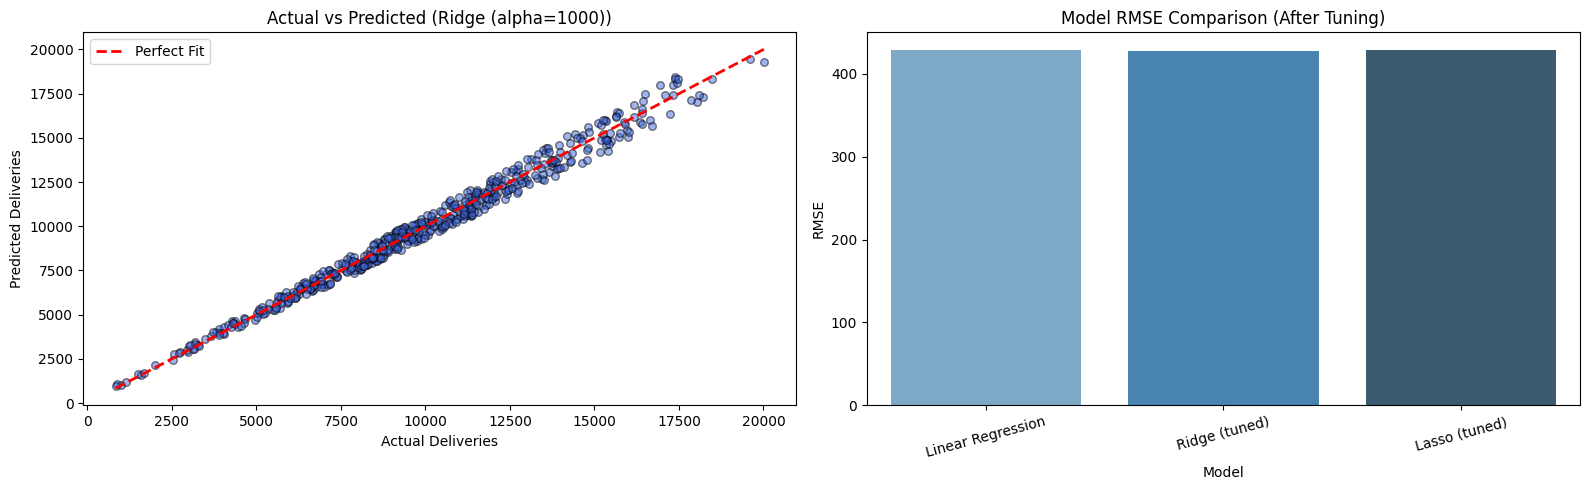

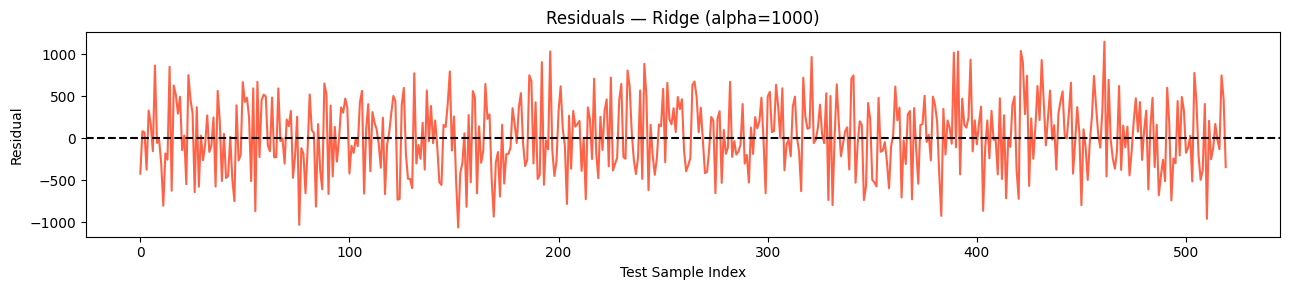

Ridge (alpha=1000)
MAE  : 353.5747
RMSE : 427.7195
R²   : 0.9864


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].scatter(y_test, best_preds, alpha=0.5, color='royalblue', edgecolors='k', s=30)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect Fit')
axes[0].set_xlabel('Actual Deliveries')
axes[0].set_ylabel('Predicted Deliveries')
axes[0].set_title(f'Actual vs Predicted ({best_name})')
axes[0].legend()

comparison_df = pd.DataFrame([
    {'Model': 'Linear Regression', 'RMSE': np.sqrt(mean_squared_error(y_test, trained_models['Linear Regression'][1]))},
    {'Model': 'Ridge (tuned)',     'RMSE': np.sqrt(mean_squared_error(y_test, ridge_best_preds))},
    {'Model': 'Lasso (tuned)',     'RMSE': np.sqrt(mean_squared_error(y_test, lasso_best_preds))},
])
sns.barplot(data=comparison_df, x='Model', y='RMSE', palette='Blues_d', ax=axes[1])
axes[1].set_title('Model RMSE Comparison (After Tuning)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

residuals = y_test.values - best_preds
plt.figure(figsize=(13, 3))
plt.plot(residuals, color='tomato', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', lw=1.5)
plt.title(f'Residuals — {best_name}')
plt.xlabel('Test Sample Index')
plt.ylabel('Residual')
plt.tight_layout()
plt.show()

print(f"{best_name}")
print(f"MAE  : {mean_absolute_error(y_test, best_preds):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, best_preds)):.4f}")
print(f"R²   : {r2_score(y_test, best_preds):.4f}")

# 10. Time Series Decomposition

In [43]:
ts = df.groupby('Date')['Estimated_Deliveries'].sum().sort_index()

In [44]:
decomp = seasonal_decompose(ts, model='additive', period=12)

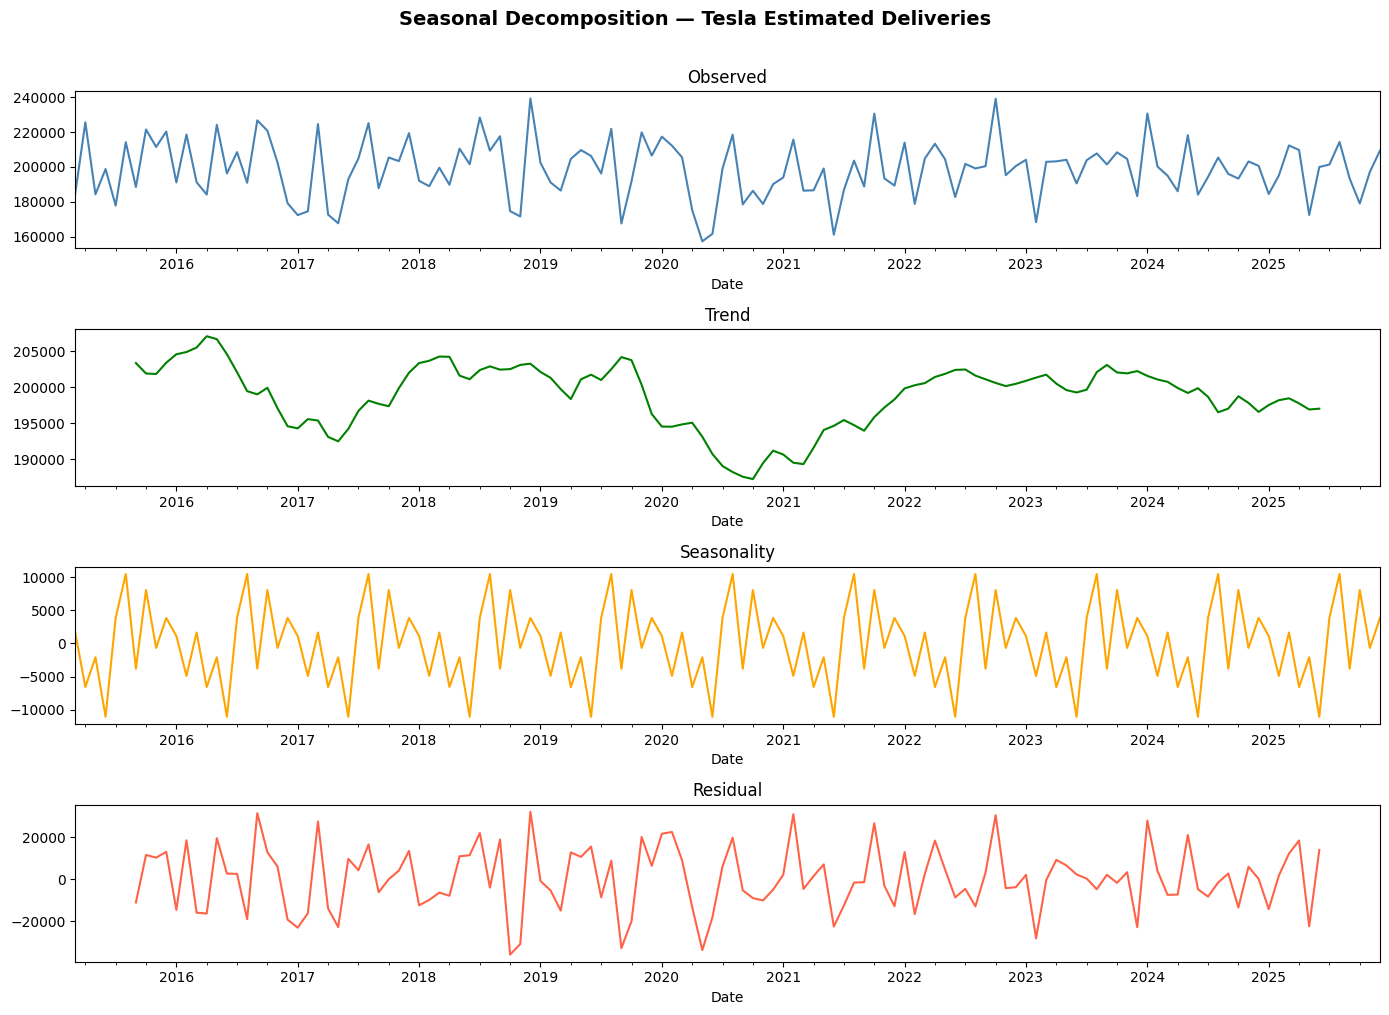

In [45]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10))
decomp.observed.plot(ax=axes[0], color='steelblue');  axes[0].set_title('Observed')
decomp.trend.plot(ax=axes[1], color='green');          axes[1].set_title('Trend')
decomp.seasonal.plot(ax=axes[2], color='orange');      axes[2].set_title('Seasonality')
decomp.resid.plot(ax=axes[3], color='tomato');         axes[3].set_title('Residual')

plt.suptitle('Seasonal Decomposition — Tesla Estimated Deliveries',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [46]:
adf_result = adfuller(ts.dropna())
print(f"ADF Statistic : {adf_result[0]:.4f}")
print(f"p-value       : {adf_result[1]:.4f}")
print(f"Series is     : {'STATIONARY' if adf_result[1] < 0.05 else 'NON-STATIONARY'}")

ADF Statistic : -11.4203
p-value       : 0.0000
Series is     : STATIONARY


# 11. Forecasting

In [47]:
train_ts = ts.iloc[:-12]
test_ts  = ts.iloc[-12:]

In [48]:
hw_model = ExponentialSmoothing(
    train_ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)

hw_forecast = hw_model.forecast(steps=12)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [49]:
hw_mae  = mean_absolute_error(test_ts, hw_forecast)
hw_rmse = np.sqrt(mean_squared_error(test_ts, hw_forecast))
print(f"Holt-Winters Validation →  MAE: {hw_mae:.2f}  |  RMSE: {hw_rmse:.2f}")

Holt-Winters Validation →  MAE: 11011.66  |  RMSE: 13904.51


In [50]:
print("Time series stats:")
print(ts.describe().round(2))
print(f"\nMean monthly total: {ts.mean():,.0f}")
print(f"MAE as % of mean:  {(hw_mae / ts.mean() * 100):.1f}%")

Time series stats:
count       130.00
mean     198818.26
std       16687.18
min      157228.00
25%      187893.00
50%      200072.00
75%      209382.00
max      239351.00
Name: Estimated_Deliveries, dtype: float64

Mean monthly total: 198,818
MAE as % of mean:  5.5%


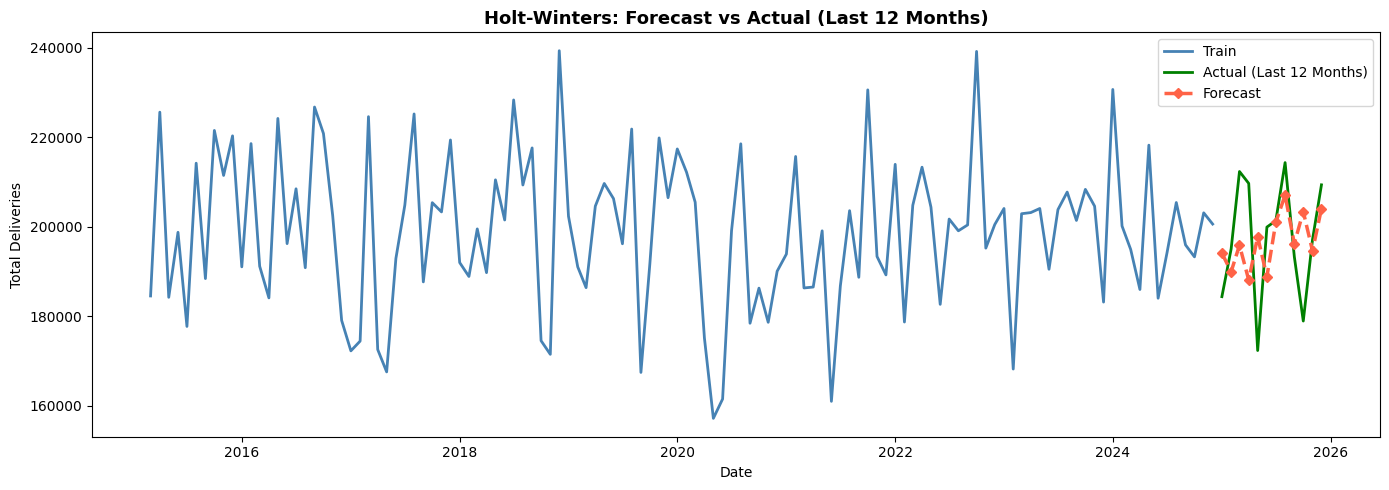

In [51]:
plt.figure(figsize=(14, 5))
plt.plot(train_ts.index, train_ts.values,
         label='Train', color='steelblue', linewidth=2)
plt.plot(test_ts.index, test_ts.values,
         label='Actual (Last 12 Months)', color='green', linewidth=2)
plt.plot(hw_forecast.index, hw_forecast.values,
         label='Forecast', color='tomato', linewidth=2.5,
         linestyle='--', marker='D', markersize=5)
plt.title('Holt-Winters: Forecast vs Actual (Last 12 Months)',
          fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

# 12. Future Forecasting

In [52]:
final_hw = ExponentialSmoothing(
    ts,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [53]:
future_forecast = final_hw.forecast(steps=12)
future_index = pd.date_range(start='2026-01-01', periods=12, freq='MS')
future_forecast.index = future_index

In [54]:
simulations = final_hw.simulate(nsimulations=12, repetitions=1000, 
                                error='add')
lower_bound = simulations.quantile(0.05, axis=1)
upper_bound = simulations.quantile(0.95, axis=1)
lower_bound.index = future_index
upper_bound.index = future_index

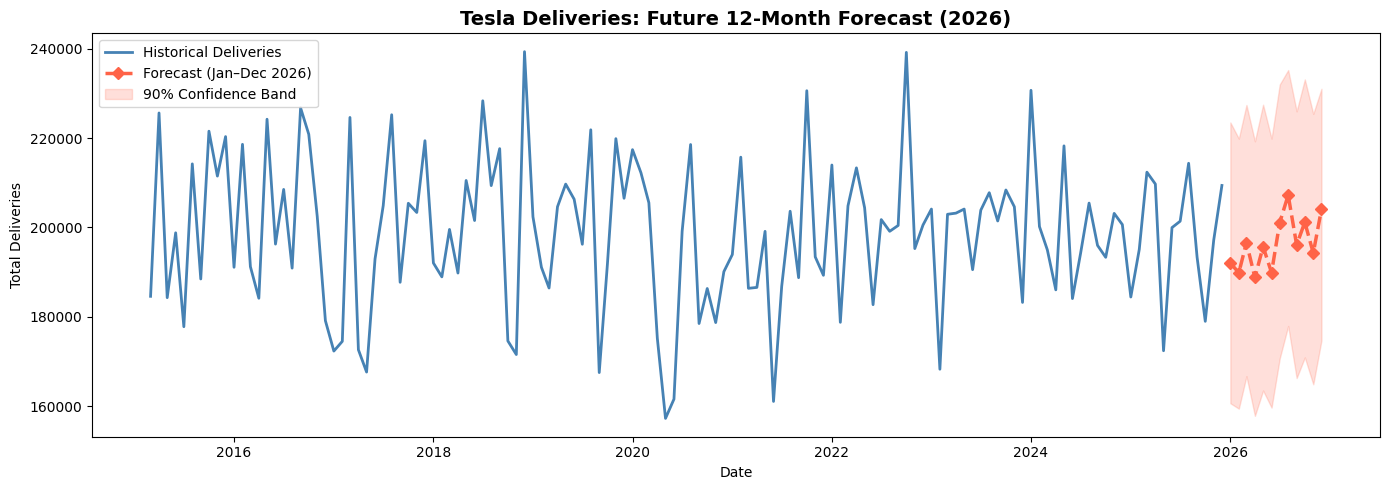

In [55]:
plt.figure(figsize=(14, 5))
plt.plot(ts.index, ts.values,
         label='Historical Deliveries', color='steelblue', linewidth=2)
plt.plot(future_forecast.index, future_forecast.values,
         label='Forecast (Jan–Dec 2026)', color='tomato',
         linewidth=2.5, linestyle='--', marker='D', markersize=6)
plt.fill_between(future_index,
                 lower_bound.values,
                 upper_bound.values,
                 alpha=0.2, color='tomato', label='90% Confidence Band')
plt.title('Tesla Deliveries: Future 12-Month Forecast (2026)',
          fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Deliveries')
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
forecast_df = pd.DataFrame({
    'Forecast': future_forecast.values.round(0).astype(int),
    'Lower (5%)': lower_bound.values.round(0).astype(int),
    'Upper (95%)': upper_bound.values.round(0).astype(int)
}, index=future_index.strftime('%b %Y'))
print(forecast_df.to_string())

          Forecast  Lower (5%)  Upper (95%)
Jan 2026    192036      160616       223498
Feb 2026    189826      159413       219886
Mar 2026    196583      166686       227409
Apr 2026    188788      157796       219278
May 2026    195688      163463       227474
Jun 2026    189874      159641       219879
Jul 2026    201068      170671       231987
Aug 2026    207235      177924       235231
Sep 2026    196078      166258       225988
Oct 2026    201162      170880       233137
Nov 2026    194250      164862       225414
Dec 2026    204064      174683       231038
